<a href="https://colab.research.google.com/github/rdvergara-feua/test1/blob/main/parking_demo_MIDTERM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Step 1
%pip install streamlit pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 29.9 MB/s eta 0:00:00


In [ ]:
#Step 2
from google.colab import files
upload = files.upload()

Saving parking_spaces_raw.csv to parking_spaces_raw.csv


In [ ]:
#Step 3
!ls

parking_spaces_raw.csv	sample_data


In [ ]:
#Step 4
import os
print(os.listdir("/content"))

['.config', 'parking_spaces_raw.csv', 'sample_data']


In [ ]:
#Step 5
!ls -l /content

total 8
-rw-r--r-- 1 root root 1739 Sep 30 00:52 parking_spaces_raw.csv
drwxr-xr-x 1 root root 4096 Sep 16 13:26 sample_data


In [ ]:
%%writefile core.py
#Step 6
import pandas as pd
import numpy as np

ZONES = ["Library", "Engineering", "Admin", "Gym", "Dormitory"]
W = {"zone": 0.30, "access": 0.25, "avail": 0.20, "duration": 0.15, "distance": 0.10}
STRONG = 0.70


def clean(df):
    df = df.copy()
    for c in ["space_id", "zone", "available", "accessible"]:
        df[c] = df[c].astype(str).str.strip().str.title().replace({"": np.nan, "Nan": np.nan})
    df["space_id"] = df["space_id"].str.upper()
    df = df.dropna().drop_duplicates("space_id")
    return df[df.zone.isin(ZONES)].reset_index(drop=True)


def validate(zone, hours):
    errs = []
    if zone not in ZONES:
        errs.append("Select a valid zone.")
    if hours is None or hours <= 0:
        errs.append("Duration must be above 0.")
    elif hours > 12:
        errs.append("Duration max is 12 hours.")
    return errs


def reasons(r, zone, need, hours):
    out = ["zone match" if r.zone == zone else f"other zone ({r.zone})",
           "available" if r.available == "Yes" else "occupied"]
    if need == "Yes":
        out.append("accessible" if r.accessible == "Yes" else "not accessible")
    elif r.accessible == "Yes":
        out.append("accessible bay (reserved)")
    out.append("fits duration" if r.max_hours >= hours else f"limit {r.max_hours}h")
    out.append(f"{r.distance_m}m away")
    return ", ".join(out)


def weighted(df, zone, need, hours, avail_mode="Available only"):
    d = df.copy()
    acc = d.accessible == "Yes"
    s_zone = (d.zone == zone).astype(float)
    s_acc = np.where(need == "Yes", acc.astype(float), np.where(acc, 0.3, 1.0))
    s_av = (d.available == "Yes").astype(float) if avail_mode == "Available only" else 1.0
    s_dur = np.minimum(d.max_hours / hours, 1.0)
    s_dist = 1 - d.distance_m / d.distance_m.max()
    d["score"] = (W["zone"] * s_zone + W["access"] * s_acc + W["avail"] * s_av
                  + W["duration"] * s_dur + W["distance"] * s_dist).round(3)
    d["why"] = d.apply(lambda r: reasons(r, zone, need, hours), axis=1)
    return d.sort_values(["score", "distance_m"], ascending=[False, True])


def rule_based(df, zone, need, hours, avail_mode="Available only"):
    m = (df.zone == zone) & (df.max_hours >= hours)
    m &= (df.accessible == "Yes") if need == "Yes" else (df.accessible == "No")
    if avail_mode == "Available only":
        m &= df.available == "Yes"
    d = df[m].sort_values("distance_m").copy()
    d["why"] = d.apply(lambda r: reasons(r, zone, need, hours), axis=1)
    return d


def recommend(df, zone, need, hours, avail_mode="Available only", k=3):
    return weighted(df, zone, need, hours, avail_mode).head(k), rule_based(df, zone, need, hours, avail_mode)

Writing core.py


In [ ]:
#Step 7
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from core import *

raw = pd.read_csv("parking_spaces_raw.csv")
#raw = pd.read_csv("PASTE_LINK_HERE")

print(raw.shape)
raw.tail(8)

(64, 6)


,space_id,zone,available,accessible,max_hours,distance_m
56,P057,Admin,No,No,8,390
57,P058,Engineering,Yes,Yes,8,260
58,P059,Library,No,No,2,198
59,P060,Dormitory,No,Yes,4,222
60,P001,Dormitory,Yes,No,2,386
61,P061,library,YES,no,4,120
62,P062,NaN,Yes,No,2,90
63,P063,gym,yes,NO,8,200


In [ ]:
#Step 8
dictionary = pd.DataFrame([
    ["space_id", "Reference only", "Unique parking space ID"],
    ["zone", "Input", "Campus zone of the space"],
    ["available", "Input", "Yes/No availability"],
    ["accessible", "Input", "Accessible bay (Yes/No)"],
    ["max_hours", "Input", "Max parking duration allowed"],
    ["distance_m", "Input", "Distance to zone entrance (m)"],
    ["(target label)", "None", "Unsupervised, no label needed"],
    ["recommended space", "Output", "Top-ranked space + score + reason"],
], columns=["field", "role", "description"])
dictionary

,field,role,description
0,space_id,Reference only,Unique parking space ID
1,zone,Input,Campus zone of the space
2,available,Input,Yes/No availability
3,accessible,Input,Accessible bay (Yes/No)
4,max_hours,Input,Max parking duration allowed
5,distance_m,Input,Distance to zone entrance (m)
6,(target label),None,"Unsupervised, no label needed"
7,recommended space,Output,Top-ranked space + score + reason


In [ ]:
#Step 9
blank = (raw.astype(str).apply(lambda c: c.str.strip() == "")).sum().sum()
print("rows before:", len(raw))
print("duplicate IDs:", raw.space_id.duplicated().sum())
print("blank cells:", blank)

df = clean(raw)
df.to_csv("parking_clean.csv", index=False)
print("rows after:", len(df))
print(df.zone.value_counts().to_dict())
df.head()

rows before: 64
duplicate IDs: 1
blank cells: 0
rows after: 62
{'Dormitory': 17, 'Engineering': 14, 'Admin': 13, 'Gym': 10, 'Library': 8}


,space_id,zone,available,accessible,max_hours,distance_m
0,P001,Dormitory,Yes,No,2,386
1,P002,Gym,No,No,4,395
2,P003,Gym,Yes,No,12,140
3,P004,Dormitory,Yes,No,12,92
4,P005,Engineering,Yes,No,8,289


In [ ]:
#Step 10
zone, need, hours = "Library", "No", 4.0

w, r = recommend(df, zone, need, hours, k=3)
print("WEIGHTED SCORING")
display(w[["space_id", "zone", "distance_m", "score", "why"]])
print("RULE-BASED FILTERING")
display(r.head(3)[["space_id", "zone", "distance_m", "why"]])
print("Recommended:", w.iloc[0].space_id, "| score", w.iloc[0].score)

WEIGHTED SCORING


,space_id,zone,distance_m,score,why
11,P012,Library,114,0.971,"zone match, available, fits duration, 114m away"
60,P061,Library,120,0.970,"zone match, available, fits duration, 120m away"
7,P008,Library,191,0.952,"zone match, available, fits duration, 191m away"


RULE-BASED FILTERING


,space_id,zone,distance_m,why
11,P012,Library,114,"zone match, available, fits duration, 114m away"
60,P061,Library,120,"zone match, available, fits duration, 120m away"
7,P008,Library,191,"zone match, available, fits duration, 191m away"


Recommended: P012 | score 0.971


In [ ]:
#Step 11
cases = [
    ("Normal", "Library", "No", 4.0),
    ("Accessible", "Engineering", "Yes", 4.0),
    ("Boundary 12h", "Admin", "No", 12.0),
    ("Boundary 0.5h", "Gym", "No", 0.5),
    ("Uncertain", "Dormitory", "Yes", 12.0),
    ("Missing zone", "", "No", 4.0),
    ("Invalid hrs", "Library", "No", 0),
]

rows = []
for name, z, n, h in cases:
    errs = validate(z, h)
    if errs:
        rows.append([name, None, "-", "-", None, errs[0]])
        continue
    w, r = recommend(df, z, n, h)
    top = w.iloc[0]
    rows.append([name, len(r), r.space_id.iloc[0] if len(r) else "none",
                 top.space_id, top.score, "Strong" if top.score >= STRONG else "Weak"])

results = pd.DataFrame(rows, columns=["case", "rule_matches", "rule_top", "weighted_top", "score", "status"])
results

,case,rule_matches,rule_top,weighted_top,score,status
0,Normal,5.0,P012,P012,0.971,Strong
1,Accessible,4.0,P054,P054,0.980,Strong
2,Boundary 12h,2.0,P047,P047,0.932,Strong
3,Boundary 0.5h,6.0,P039,P039,0.965,Strong
4,Uncertain,0.0,none,P044,0.888,Strong
5,Missing zone,NaN,-,-,NaN,Select a valid zone.
6,Invalid hrs,NaN,-,-,NaN,Duration must be above 0.


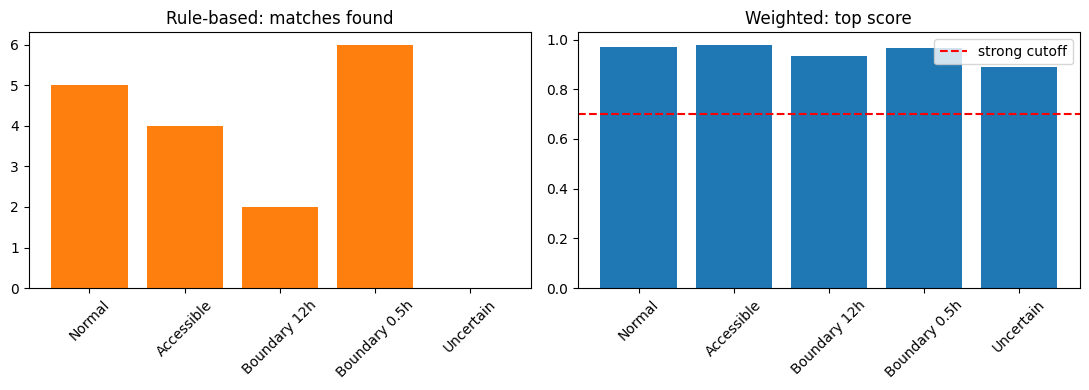

In [ ]:
#Step 12
ok = results.dropna(subset=["score"])
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(ok.case, ok.rule_matches, color="tab:orange")
ax[0].set_title("Rule-based: matches found")
ax[1].bar(ok.case, ok.score, color="tab:blue")
ax[1].axhline(STRONG, color="red", ls="--", label="strong cutoff")
ax[1].set_title("Weighted: top score")
ax[1].legend()
for a in ax:
    a.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
%%writefile streamlit_app.py
#Step 13
import pandas as pd
import streamlit as st
from core import *

st.set_page_config(page_title="Campus Parking", page_icon="🅿️", layout="wide")
st.title("Campus Parking Space Allocation")

st.info("Recommendations support parking staff and students. Accessible bays stay reserved for users who need them.")


@st.cache_data
def load():
    return clean(pd.read_csv("/content/parking_clean.csv"))


df = load()

with st.form("parking_form"):
    zone = st.selectbox("Requested zone", ["Select zone"] + ZONES)
    avail = st.radio("Space availability", ["Available only", "Any"], horizontal=True)
    need = st.radio("Accessibility need", ["No", "Yes"], horizontal=True)
    hours = st.number_input("Parking duration (hours)", value=4.0, step=0.5)
    k = st.slider("Top k", 3, 5, 3)
    go = st.form_submit_button("Find Parking", type="primary")

if go:
    errs = validate(zone, hours)
    for e in errs:
        st.error(e)
    if not errs:
        w, r = recommend(df, zone, need, hours, avail, k)
        best = w.iloc[0]
        if best.score >= STRONG:
            st.success(f"Recommended: {best.space_id} ({best.zone}), score {best.score}")
        else:
            st.warning(f"No strong match. Closest: {best.space_id}, score {best.score}")
        st.write("Why:", best.why)

        st.subheader("Weighted scoring")
        st.dataframe(w[["space_id", "zone", "distance_m", "score", "why"]], hide_index=True)

        st.subheader(f"Rule-based filtering ({len(r)} matches)")
        if r.empty:
            st.warning("No record passes all rules.")
        else:
            st.dataframe(r.head(k)[["space_id", "zone", "distance_m", "why"]], hide_index=True)

        st.bar_chart(w.set_index("space_id")["score"])

Writing streamlit_app.py


In [ ]:
#Step 14
!ls

core.py		   parking_spaces_raw.csv  sample_data
parking_clean.csv  __pycache__		   streamlit_app.py


In [ ]:
#Step 15
!pkill -9 -f "streamlit run" || true

^C


In [ ]:
#Step 16
!streamlit run /content/streamlit_app.py \
    --server.port 8502 \
    --server.address 0.0.0.0 \
    --server.headless true \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    --server.enableWebsocketCompression false \
    > /content/streamlit_log_8502.txt 2>&1 &

In [ ]:
#Step 17
from google.colab.output import eval_js

app_url = eval_js(
    "google.colab.kernel.proxyPort(8502)"
)

print("Open this new link:", app_url)

Open this new link: https://8502-m-s-kkb-usw4c1-rjiu6lk36yts-c.us-west4-1.prod.colab.dev
